# 03 Baseline Model (Week 4)

This notebook completes the Week 4 baseline-model task by training and evaluating a simple `LinearRegression` model using the cleaned Week 3 train/test datasets.


## Week 4 Goal

The Week 4 objective is to build a first baseline model, evaluate it on the time-based holdout set, and record the baseline results clearly. The train/test split comes directly from Week 3 preprocessing, where the most recent available month (`2026-05`) is used as the test set and the prior months are used for training.


In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.2f}".format)
plt.style.use("ggplot")


In [12]:
processed_dir = Path("../data/processed")
train_path = processed_dir / "train_preprocessed.csv"
test_path = processed_dir / "test_preprocessed.csv"

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        "Run 02_preprocessing.ipynb first so the processed train/test files exist."
    )

train_df = pd.read_csv(train_path, parse_dates=["CloseDate", "close_month"])
test_df = pd.read_csv(test_path, parse_dates=["CloseDate", "close_month"])

print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
display(train_df.head())


Train rows: 59,345
Test rows: 12,007


,ClosePrice,CloseDate,close_month,ListPrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,YearBuilt,Latitude,Longitude,DaysOnMarket,property_age,log_living_area,bathrooms_per_bedroom,CountyOrParish
0,1250000.00,2025-11-30,2025-11-01,1250000.00,1027.00,3.00,2.00,5913.00,1961.00,33.68,-118.00,0.00,64.00,6.94,0.67,Orange
1,2299995.00,2025-11-20,2025-11-01,2299995.00,1129.00,3.00,1.00,18432.00,1949.00,37.26,-121.93,0.00,76.00,7.03,0.33,Santa Clara
2,810000.00,2025-11-26,2025-11-01,799900.00,1619.00,4.00,3.00,5300.00,1978.00,32.56,-117.06,0.00,47.00,7.39,0.75,San Diego
3,925000.00,2025-11-17,2025-11-01,925000.00,2872.00,5.00,3.00,5272.00,2000.00,32.58,-117.02,0.00,25.00,7.96,0.60,San Diego
4,1300000.00,2025-11-25,2025-11-01,1300000.00,1727.00,3.00,2.00,10500.00,1950.00,35.55,-120.71,0.00,75.00,7.45,0.67,San Luis Obispo


## Candidate Baselines

To keep the baseline simple but stable, this notebook compares a few closely related linear-regression setups. The main comparison is whether simplifying the geography features improves performance and whether a log-target specification is more stable than predicting raw `ClosePrice` directly.


In [13]:
target_col = "ClosePrice"
base_exclude_cols = ["ClosePrice", "CloseDate", "close_month"]
available_feature_cols = [
    col for col in train_df.columns if col not in base_exclude_cols
]

candidate_feature_sets = {
    "county_only_raw_target": [
        "ListPrice",
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
        "YearBuilt",
        "Latitude",
        "Longitude",
        "DaysOnMarket",
        "property_age",
        "log_living_area",
        "bathrooms_per_bedroom",
        "CountyOrParish",
    ],
    "county_only_log_target": [
        "ListPrice",
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
        "YearBuilt",
        "Latitude",
        "Longitude",
        "DaysOnMarket",
        "property_age",
        "log_living_area",
        "bathrooms_per_bedroom",
        "CountyOrParish",
    ],
    "no_geo_log_target": [
        "ListPrice",
        "LivingArea",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "LotSizeSquareFeet",
        "YearBuilt",
        "DaysOnMarket",
        "property_age",
        "log_living_area",
        "bathrooms_per_bedroom",
    ],
}

for model_name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in available_feature_cols]
    if missing_cols:
        raise ValueError(f"{model_name} is missing columns: {missing_cols}")

y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()
display(
    pd.DataFrame(
        {
            "model_name": candidate_feature_sets.keys(),
            "feature_count": [len(v) for v in candidate_feature_sets.values()],
        }
    )
)


,model_name,feature_count
0,county_only_raw_target,13
1,county_only_log_target,13
2,no_geo_log_target,10


In [14]:
def build_model(feature_cols, use_log_target=False):
    X_train = train_df[feature_cols].copy()
    numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = [col for col in feature_cols if col not in numeric_features]

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LinearRegression()),
        ]
    )

    if use_log_target:
        pipeline = TransformedTargetRegressor(
            regressor=pipeline,
            func=np.log1p,
            inverse_func=np.expm1,
        )

    return pipeline, numeric_features, categorical_features


In [15]:
model_specs = [
    ("county_only_raw_target", candidate_feature_sets["county_only_raw_target"], False),
    ("county_only_log_target", candidate_feature_sets["county_only_log_target"], True),
    ("no_geo_log_target", candidate_feature_sets["no_geo_log_target"], True),
]

results = []
predictions_by_model = {}
fitted_models = {}
feature_sets_used = {}

for model_name, feature_cols, use_log_target in model_specs:
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()
    model, numeric_features, categorical_features = build_model(
        feature_cols, use_log_target=use_log_target
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append(
        {
            "model_name": model_name,
            "log_target": use_log_target,
            "feature_count": len(feature_cols),
            "numeric_feature_count": len(numeric_features),
            "categorical_feature_count": len(categorical_features),
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
            "R2": r2_score(y_test, preds),
        }
    )
    predictions_by_model[model_name] = preds
    fitted_models[model_name] = model
    feature_sets_used[model_name] = feature_cols

results_df = (
    pd.DataFrame(results)
    .sort_values(["R2", "MAE"], ascending=[False, True])
    .reset_index(drop=True)
)
display(results_df)

best_model_name = results_df.loc[0, "model_name"]
best_model = fitted_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]
best_feature_cols = feature_sets_used[best_model_name]
print(f"Best current baseline: {best_model_name}")
print(f"Features used: {best_feature_cols}")


,model_name,log_target,feature_count,numeric_feature_count,categorical_feature_count,MAE,RMSE,R2
0,county_only_raw_target,False,13,12,1,176134.11,1010179.09,0.64
1,county_only_log_target,True,13,12,1,746444.64,28076185.49,-279.33
2,no_geo_log_target,True,10,10,0,3608747.81,258355311.68,-23736.27


Best current baseline: county_only_raw_target
Features used: ['ListPrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet', 'YearBuilt', 'Latitude', 'Longitude', 'DaysOnMarket', 'property_age', 'log_living_area', 'bathrooms_per_bedroom', 'CountyOrParish']


In [16]:
comparison_df = test_df[["CloseDate", "close_month"]].copy()
comparison_df["actual"] = y_test.values
comparison_df["predicted"] = best_predictions
comparison_df["residual"] = comparison_df["actual"] - comparison_df["predicted"]
comparison_df["abs_error"] = comparison_df["residual"].abs()
comparison_df["ape"] = comparison_df["abs_error"] / comparison_df["actual"]
comparison_df["model_name"] = best_model_name

display(comparison_df.head())


,CloseDate,close_month,actual,predicted,residual,abs_error,ape,model_name
0,2026-05-28,2026-05-01,8712500.00,7876944.84,835555.16,835555.16,0.10,county_only_raw_target
1,2026-05-29,2026-05-01,1100000.00,1795529.81,-695529.81,695529.81,0.63,county_only_raw_target
2,2026-05-28,2026-05-01,1625000.00,1379430.00,245570.00,245570.00,0.15,county_only_raw_target
3,2026-05-15,2026-05-01,1560000.00,1665437.54,-105437.54,105437.54,0.07,county_only_raw_target
4,2026-05-29,2026-05-01,605000.00,629705.61,-24705.61,24705.61,0.04,county_only_raw_target


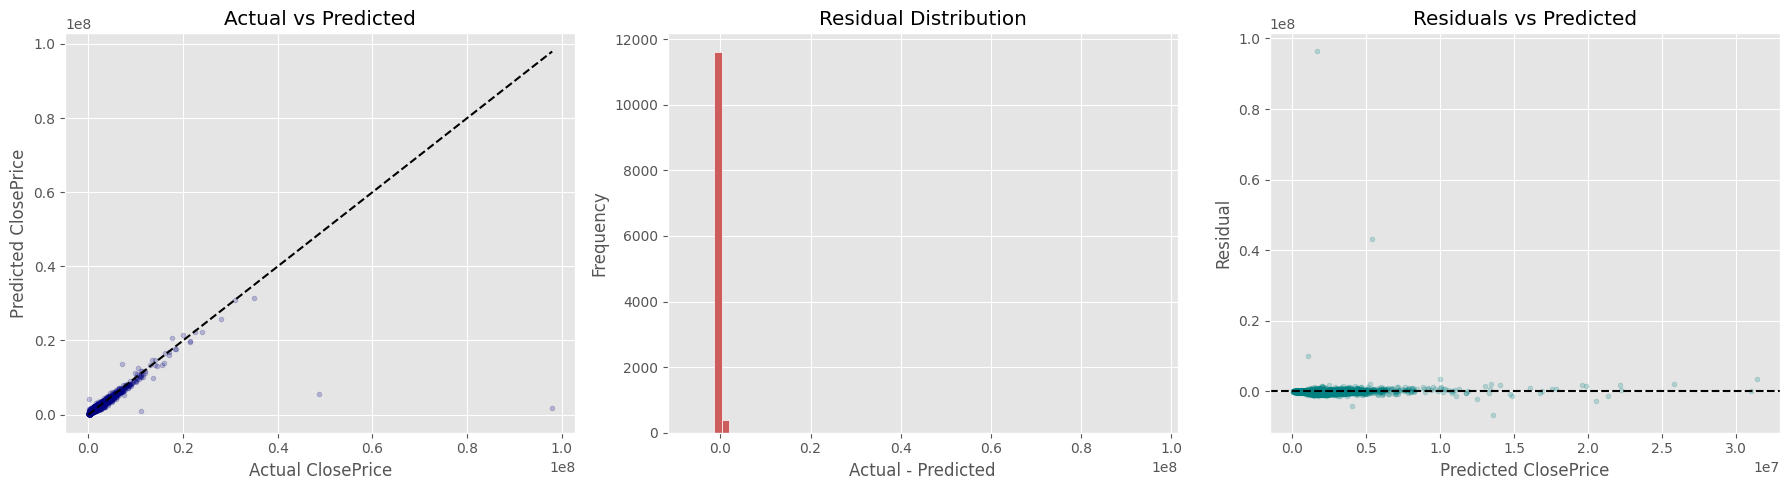

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(
    comparison_df["actual"], comparison_df["predicted"], alpha=0.22, s=12, color="navy"
)
plot_max = max(comparison_df["actual"].max(), comparison_df["predicted"].max())
axes[0].plot([0, plot_max], [0, plot_max], linestyle="--", color="black")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual ClosePrice")
axes[0].set_ylabel("Predicted ClosePrice")

comparison_df["residual"].plot(
    kind="hist", bins=60, ax=axes[1], color="indianred", edgecolor="white"
)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Actual - Predicted")

axes[2].scatter(
    comparison_df["predicted"],
    comparison_df["residual"],
    alpha=0.22,
    s=12,
    color="teal",
)
axes[2].axhline(0, linestyle="--", color="black")
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted ClosePrice")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()


## Week 4 Baseline Takeaways

This baseline should be interpreted as a first benchmark rather than a final model. The main goal is to establish a reproducible, time-based evaluation setup and a simple regression result that later models can beat.

Suggested points to report from this notebook:

1. The baseline uses a time-based holdout split with `2026-05` as the test set.
2. A simplified location strategy performs better than the earlier high-cardinality geography setup.
3. The selected baseline still has limitations, especially on extreme luxury properties and unusual transactions.
4. Future work should compare this baseline against tree-based models and stronger feature engineering.


## Best Model Interpretation

The final baseline is selected by comparing the simple candidate models above and keeping the setup with the strongest test-set `R²` and the most reasonable overall error profile. In this project, simplifying the location fields is especially important because high-cardinality variables such as `City` and `PostalCode` can make a linear model unstable.


/tmp/ipykernel_68246/504745364.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("price_band")


,price_band,row_count,median_actual,mean_abs_error,median_ape
0,"(11899.999, 448599.4]",1201,369000.00,88215.63,0.20
1,"(448599.4, 580000.0]",1217,518492.00,94093.03,0.15
2,"(580000.0, 695892.0]",1184,640000.00,107255.97,0.11
3,"(695892.0, 807500.0]",1202,750000.00,146766.80,0.09
4,"(807500.0, 930000.0]",1223,866000.00,189470.50,0.08
5,"(930000.0, 1125000.0]",1207,1015000.00,189723.95,0.07
6,"(1125000.0, 1350000.0]",1174,1235000.00,171975.94,0.06
7,"(1350000.0, 1690000.0]",1207,1500000.00,162642.09,0.05
8,"(1690000.0, 2400000.0]",1198,1950000.00,163384.25,0.04
9,"(2400000.0, 97972500.0]",1194,3300000.00,449176.73,0.06


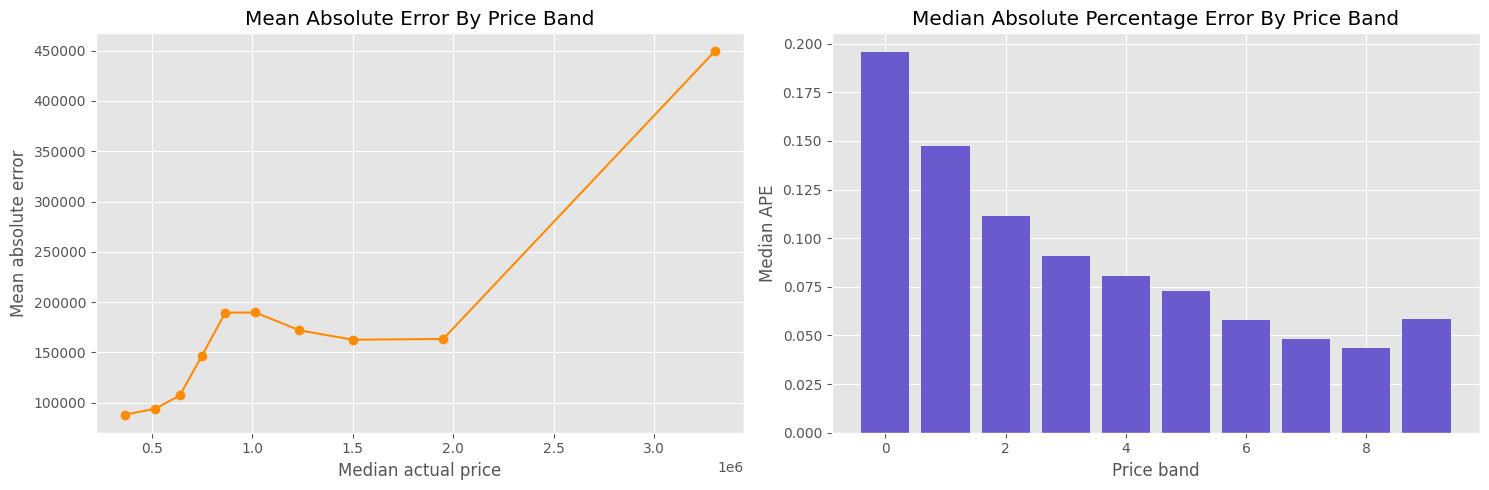

In [18]:
segment_summary = (
    comparison_df.assign(
        price_band=pd.qcut(comparison_df["actual"], q=10, duplicates="drop")
    )
    .groupby("price_band")
    .agg(
        row_count=("actual", "size"),
        median_actual=("actual", "median"),
        mean_abs_error=("abs_error", "mean"),
        median_ape=("ape", "median"),
    )
    .reset_index()
)

display(segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(
    segment_summary["median_actual"],
    segment_summary["mean_abs_error"],
    marker="o",
    color="darkorange",
)
axes[0].set_title("Mean Absolute Error By Price Band")
axes[0].set_xlabel("Median actual price")
axes[0].set_ylabel("Mean absolute error")

axes[1].bar(
    range(len(segment_summary)), segment_summary["median_ape"], color="slateblue"
)
axes[1].set_title("Median Absolute Percentage Error By Price Band")
axes[1].set_xlabel("Price band")
axes[1].set_ylabel("Median APE")

plt.tight_layout()
plt.show()


,feature,coefficient,abs_coefficient
0,num__ListPrice,1339453.40,1339453.40
9,num__property_age,1030092.81,1030092.81
5,num__YearBuilt,1016561.40,1016561.40
50,cat__CountyOrParish_San Diego,603807.52,603807.52
54,cat__CountyOrParish_San Mateo,274983.92,274983.92
51,cat__CountyOrParish_San Francisco,233543.01,233543.01
56,cat__CountyOrParish_Santa Clara,217951.40,217951.40
12,cat__CountyOrParish_Alameda,140534.53,140534.53
24,cat__CountyOrParish_Imperial,-122049.33,122049.33
3,num__BathroomsTotalInteger,-112800.27,112800.27


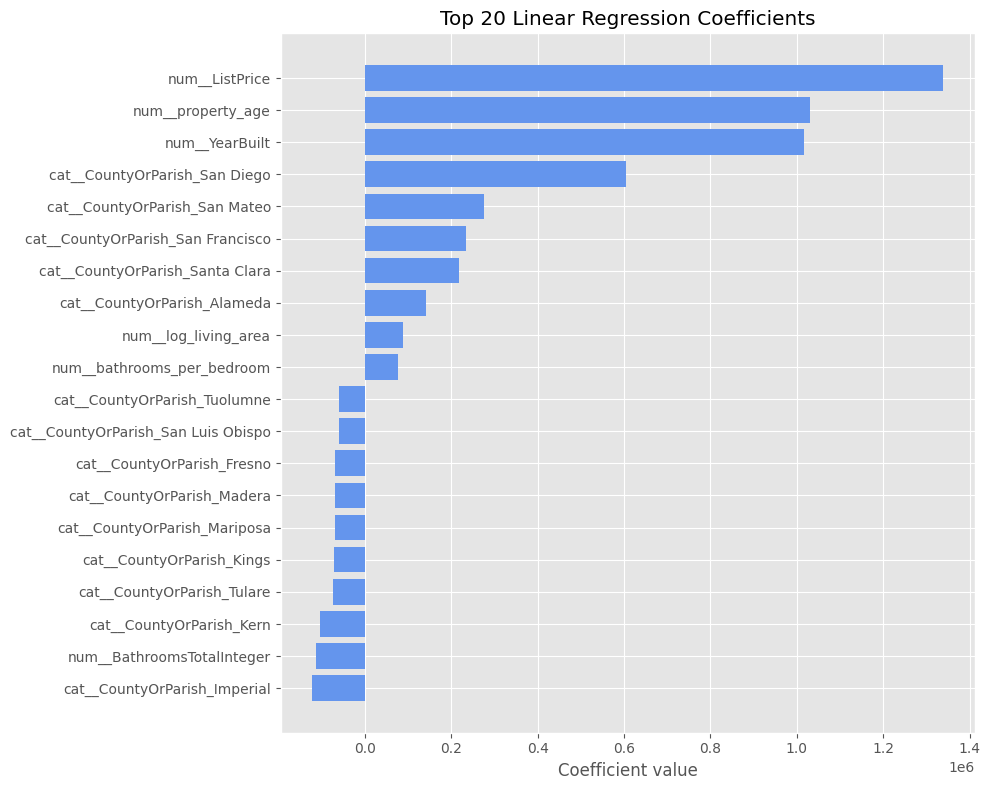

In [19]:
if isinstance(best_model, TransformedTargetRegressor):
    coefficient_pipeline = best_model.regressor_
else:
    coefficient_pipeline = best_model

feature_names = coefficient_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficient_pipeline.named_steps["model"].coef_,
    }
)
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values("abs_coefficient", ascending=False)

display(coefficients.head(20))

plot_coefficients = coefficients.head(20).sort_values("coefficient")
plt.figure(figsize=(10, 8))
plt.barh(
    plot_coefficients["feature"],
    plot_coefficients["coefficient"],
    color="cornflowerblue",
)
plt.title("Top 20 Linear Regression Coefficients")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.show()


In [20]:
prediction_output = processed_dir / "baseline_predictions_linear_regression.csv"
results_output = processed_dir / "baseline_model_results.csv"
comparison_df.to_csv(prediction_output, index=False)
results_df.to_csv(results_output, index=False)
print(f"Saved prediction diagnostics to {prediction_output}")
print(f"Saved model comparison table to {results_output}")


Saved prediction diagnostics to ../data/processed/baseline_predictions_linear_regression.csv
Saved model comparison table to ../data/processed/baseline_model_results.csv


## Final Week 4 Conclusion

Week 4 is complete once the baseline model has been trained, evaluated, and documented. In this notebook, the retained baseline is the strongest current linear-regression specification from the comparison table above, and its metrics should be carried forward as the reference point for Week 5 model comparisons.
